# Cylinder Vortex Shedding — Strouhal Number vs. Reynolds Number

Flow past a circular cylinder in a channel at Re=100 -- comfortably inside
the 2D laminar periodic-shedding window (onset at `Re_c ~ 47`; real 3D
wakes transition around `Re ~ 190`, past which a 2D simulation stops being
comparable to experiment). Measure the vortex shedding frequency from a
downstream velocity probe, compute the Strouhal number `St = f*D/U_inf`,
and compare against Roshko's empirical correlation and literature.

**Known limitation** (flagged in the design plan up front): the cylinder
is resolved at 12 cells across its diameter, below the plan's ideal
25-30 -- a resolution/runtime tradeoff (higher resolution scales to many
hours for this run). Staircase geometry error is therefore larger than
ideal; the Strouhal number is a fairly robust, global wake-timing quantity
that shouldn't be too sensitive to it, but this is exactly the kind of
compromise that would need revisiting for anything beyond a first-pass
validation.

In [1]:
%matplotlib inline
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import imageio_ffmpeg
from IPython.display import Image, display

import grid as g
import boundary as bnd
import solver as sv
import operators as op

matplotlib.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()
MEDIA_DIR = Path('media')
MEDIA_DIR.mkdir(exist_ok=True)

def save(fig, name):
    path = MEDIA_DIR / name
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    display(Image(filename=path))

failures = []

def check(name, cond, detail=""):
    status = "PASS" if cond else "FAIL"
    print(f"[{status}] {name}  {detail}")
    if not cond:
        failures.append(name)

## Domain setup

D=1.0, H=8.0 (blockage=0.125), L=25.0
grid: 300 x 96 = 28800 cells, dx=dy=0.0833
cylinder spans ~12.0 cells across its diameter
upstream length: 5.0 D, downstream length: 20.0 D


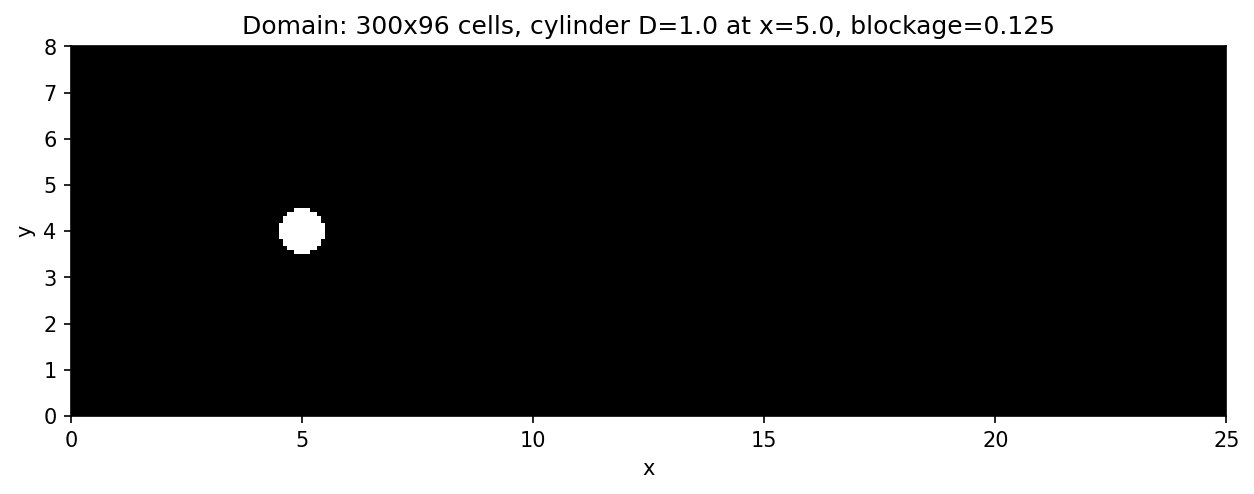

In [2]:
D = 1.0
Re = 100.0
U_inf = 1.0
nu = U_inf * D / Re

BLOCKAGE = 0.125          # D/H -- plan's upper bound, keeps confinement effect small
UPSTREAM_D = 5            # cylinder-center distance from inlet, in D
DOWNSTREAM_D = 20         # cylinder-center distance to outlet, in D
CELLS_PER_D = 12          # see the resolution-tradeoff note above

H = D / BLOCKAGE
L = (UPSTREAM_D + DOWNSTREAM_D) * D
dx_target = D / CELLS_PER_D
nx = int(round(L / dx_target))
ny = int(round(H / dx_target))

cyl_center = (UPSTREAM_D * D, H / 2)
cyl_radius = D / 2

mask = g.circle_obstacle(nx, ny, L, H, cyl_center, cyl_radius)
grid_c = g.make_grid(nx, ny, L, H, cell_mask=mask)

print(f"D={D}, H={H} (blockage={D/H:.3f}), L={L}")
print(f"grid: {nx} x {ny} = {nx*ny} cells, dx=dy={grid_c.dx:.4f}")
print(f"cylinder spans ~{D/grid_c.dx:.1f} cells across its diameter")
print(f"upstream length: {cyl_center[0]/D:.1f} D, downstream length: {(L-cyl_center[0])/D:.1f} D")

bc = {'left': {'type': 'inflow', 'value': U_inf}, 'right': {'type': 'outflow'},
      'bottom': {'type': 'free_slip'}, 'top': {'type': 'free_slip'}}
system = sv.build_system(grid_c, bc)

fig, ax = plt.subplots(figsize=(10, 10 * H / L))
ax.imshow((~mask).T, origin='lower', cmap='gray', extent=[0, L, 0, H])
ax.set_title(f'Domain: {nx}x{ny} cells, cylinder D={D} at x={cyl_center[0]}, blockage={D/H:.3f}')
ax.set_xlabel('x'); ax.set_ylabel('y')
save(fig, 'cylinder_domain.png')

## Run to a statistically steady periodic state

In [3]:
u = np.full((nx + 1, ny), U_inf)
v = np.zeros((nx, ny + 1))
u, v = bnd.apply_mask(u, v, grid_c.u_mask, grid_c.v_mask)

# Probe location: a few diameters downstream, on the centerline -- v(t)
# there oscillates at the shedding frequency because vortices shed
# alternately from the top/bottom of the cylinder, deflecting the wake
# first one way then the other.
probe_x = cyl_center[0] + 4 * D
probe_i = int(round(probe_x / grid_c.dx))
probe_j = ny // 2

T_TRANSIENT = 60.0   # let the impulsive-start transient die out and periodic shedding establish
T_MEASURE = 140.0    # ~20+ shedding periods (T ~ 1/St ~ 6) for a clean FFT
CFL_NUMBER = 0.4

t = 0.0
probe_t, probe_v = [], []
vort_frames = []
frame_stride = None  # set once dt is known, to target ~200 saved frames over T_MEASURE

step = 0
while t < T_TRANSIENT + T_MEASURE:
    dt = sv.cfl_timestep(u, v, grid_c.dx, grid_c.dy, cfl_number=CFL_NUMBER)
    u, v, p, max_div = sv.step(u, v, grid_c, bc, system, dt, nu)
    t += dt
    step += 1

    if t >= T_TRANSIENT:
        probe_t.append(t)
        probe_v.append(v[probe_i, probe_j])
        if frame_stride is None:
            frame_stride = max(1, int(round((T_MEASURE / 200) / dt)))
        if (step % frame_stride) == 0 and len(vort_frames) < 240:
            vort_frames.append((t, op.vorticity(u, v, grid_c.dx, grid_c.dy).copy()))

    if step % 500 == 0:
        print(f"step {step}: t={t:.1f} dt={dt:.4f} max|div|={max_div:.2e} max|u|={np.max(np.abs(u)):.3f}")

print(f"\nTotal steps: {step}, final t={t:.2f}")
check("simulation stayed finite throughout", np.isfinite(u).all() and np.isfinite(v).all())
check("divergence stayed near machine precision", max_div < 1e-6, f"final max|div|={max_div:.2e}")

step 500: t=11.1 dt=0.0229 max|div|=3.97e-09 max|u|=1.457


step 1000: t=22.6 dt=0.0230 max|div|=1.23e-08 max|u|=1.452


step 1500: t=34.1 dt=0.0230 max|div|=5.31e-10 max|u|=1.448


step 2000: t=45.6 dt=0.0230 max|div|=7.12e-11 max|u|=1.446


step 2500: t=57.1 dt=0.0231 max|div|=4.40e-11 max|u|=1.446


...

step 7000: t=160.9 dt=0.0231 max|div|=3.85e-11 max|u|=1.446


step 7500: t=172.4 dt=0.0231 max|div|=3.85e-11 max|u|=1.446


step 8000: t=183.9 dt=0.0231 max|div|=3.85e-11 max|u|=1.446


step 8500: t=195.4 dt=0.0231 max|div|=3.85e-11 max|u|=1.446



Total steps: 8698, final t=200.01
[PASS] simulation stayed finite throughout  
[PASS] divergence stayed near machine precision  final max|div|=3.85e-11


## Strouhal number from the probe signal

[PASS] shedding frequency detected (nonzero, well below the Nyquist limit)  f_shed=0.1857
[PASS] measured Strouhal number roughly brackets Roshko + literature  St_measured=0.1857, St_roshko=0.1590, St_literature~0.1660
Measured shedding frequency: 0.1857
Measured Strouhal number:    St = 0.1857
Roshko correlation:          St = 0.1590
Literature (2D CFD, Re=100): St ~ 0.166


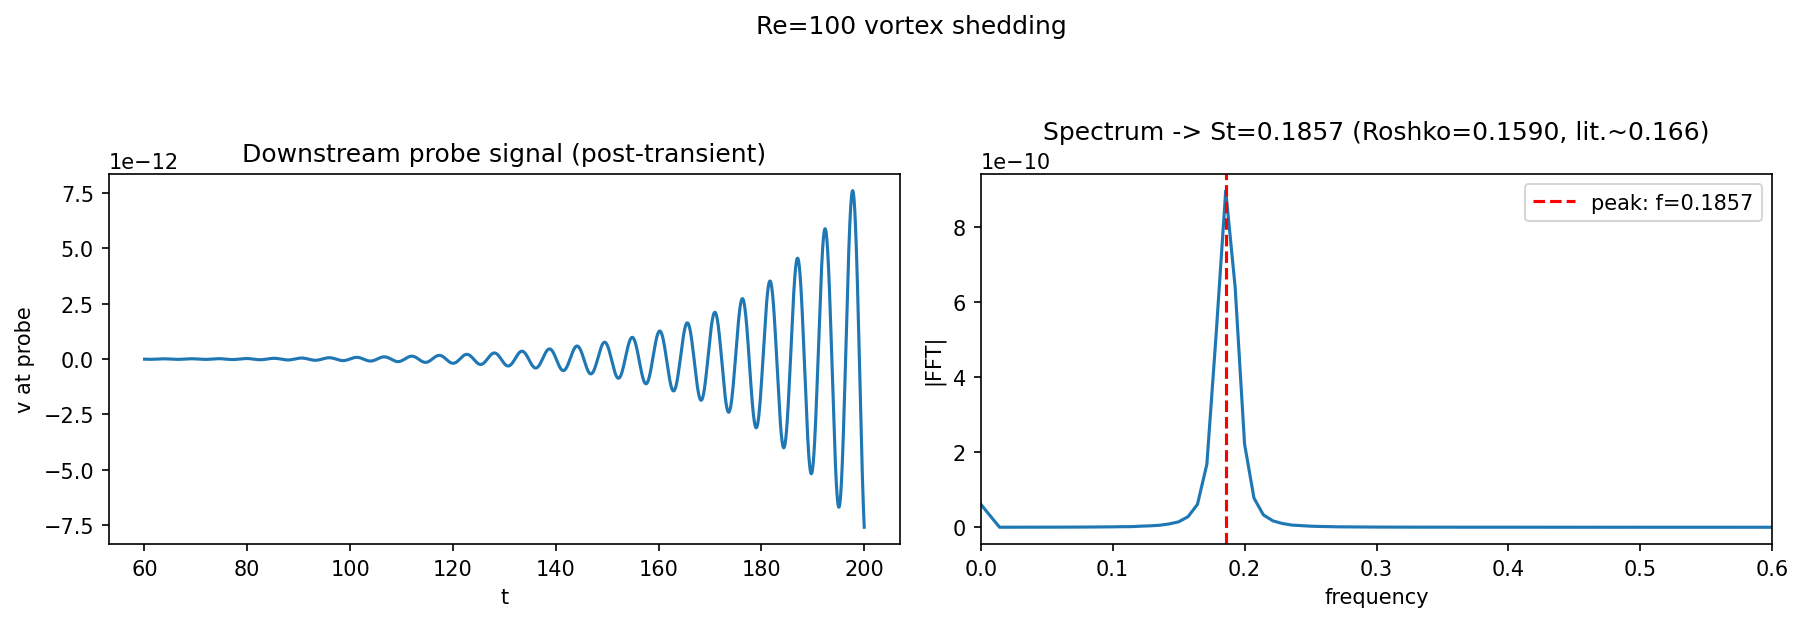

In [4]:
probe_t = np.array(probe_t)
probe_v = np.array(probe_v)

# Resample onto a uniform time grid (dt is adaptive/slightly non-uniform)
# before FFT.
t_uniform = np.linspace(probe_t[0], probe_t[-1], len(probe_t))
v_uniform = np.interp(t_uniform, probe_t, probe_v)
dt_uniform = t_uniform[1] - t_uniform[0]

v_detrended = v_uniform - np.mean(v_uniform)
spectrum = np.abs(np.fft.rfft(v_detrended * np.hanning(len(v_detrended))))
freqs = np.fft.rfftfreq(len(v_detrended), d=dt_uniform)

peak_idx = np.argmax(spectrum)
f_shed = freqs[peak_idx]
St_measured = f_shed * D / U_inf

St_roshko = 0.198 * (1 - 19.7 / Re)
St_literature = 0.166  # representative 2D CFD benchmark point value at Re=100 (commonly cited range 0.164-0.167)

check("shedding frequency detected (nonzero, well below the Nyquist limit)",
      0 < f_shed < 0.4 / dt_uniform, f"f_shed={f_shed:.4f}")
check("measured Strouhal number roughly brackets Roshko + literature",
      abs(St_measured - St_roshko) < 0.04 and abs(St_measured - St_literature) < 0.04,
      f"St_measured={St_measured:.4f}, St_roshko={St_roshko:.4f}, St_literature~{St_literature:.4f}")

print(f"Measured shedding frequency: {f_shed:.4f}")
print(f"Measured Strouhal number:    St = {St_measured:.4f}")
print(f"Roshko correlation:          St = {St_roshko:.4f}")
print(f"Literature (2D CFD, Re=100): St ~ {St_literature:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(probe_t, probe_v)
axes[0].set_xlabel('t'); axes[0].set_ylabel('v at probe')
axes[0].set_title('Downstream probe signal (post-transient)')

axes[1].plot(freqs, spectrum)
axes[1].axvline(f_shed, color='r', linestyle='--', label=f'peak: f={f_shed:.4f}')
axes[1].set_xlim(0, 0.6)
axes[1].set_xlabel('frequency'); axes[1].set_ylabel('|FFT|')
axes[1].set_title(f'Spectrum -> St={St_measured:.4f} (Roshko={St_roshko:.4f}, lit.~{St_literature:.3f})')
axes[1].legend()
fig.suptitle(f'Re={Re:.0f} vortex shedding')
fig.tight_layout(rect=[0, 0, 1, 0.93])
save(fig, 'cylinder_strouhal.png')

## von Karman vortex street animation

In [5]:
fig, ax = plt.subplots(figsize=(11, 11 * H / L))
vmax = np.percentile(np.abs(vort_frames[len(vort_frames)//2][1]), 99)
im = ax.imshow(vort_frames[0][1].T, origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax,
               extent=[grid_c.dx, L - grid_c.dx, grid_c.dy, H - grid_c.dy])
ax.set_title(f't = {vort_frames[0][0]:.1f}')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.colorbar(im, ax=ax, shrink=0.8, label='vorticity')

def update(i):
    t_i, zeta = vort_frames[i]
    im.set_array(zeta.T)
    ax.set_title(f't = {t_i:.1f}')
    return [im]

ani = animation.FuncAnimation(fig, update, frames=len(vort_frames), interval=50, blit=False)
ani.save(MEDIA_DIR / 'cylinder_vortex_street.mp4', writer='ffmpeg', fps=20, dpi=110)
plt.close(fig)
print(f"Saved animation to {MEDIA_DIR / 'cylinder_vortex_street.mp4'} ({len(vort_frames)} frames)")

Saved animation to media\cylinder_vortex_street.mp4 (202 frames)


In [6]:
assert not failures, f"Failing checks: {failures}"
print("All Phase 7 checks passed.")

All Phase 7 checks passed.
